# Dashboard Executivo: Análise Estratégica de Categorias

**Foco: Receita, Logística e Satisfação do Cliente (C-Level)**

Este relatório consolida as métricas financeiras de faturamento e cruza com os ofensores logísticos (custo de frete e atrasos) para descobrir onde o e-commerce gera lucro escalar e onde os clientes estão abandonando o funil devido a problemas na ponta da entrega. 

A abordagem constrói uma narrativa saindo da visão macro do dinheiro até chegar nas anomalias operacionais e mapas de decisão (Quadrantes).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({'figure.figsize': (14, 7), 'axes.titlesize': 16, 'axes.labelsize': 12})
pd.set_option('display.max_columns', None)

# Carregamento e Preparação Estrutural
df = pd.read_csv('../../data/processed/olist_super_dataset.csv')

date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date', 
             'order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['ord_hour'] = df['order_purchase_timestamp'].dt.hour
df['ord_month'] = df['order_purchase_timestamp'].dt.month

num_cols_to_force = ['tempo_entrega_dias', 'price', 'freight_value', 'product_photos_qty', 'atraso_entrega']
for col in num_cols_to_force:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['atraso_entrega_bool'] = df['atraso_entrega'] > 0
df_cat = df.dropna(subset=['product_category_name']).copy()

# Criação do DataFrame Sintético (Visão Skywork)
df_metrics = df_cat.groupby('product_category_name').agg(
    volume_pedidos=('order_id', 'count'),
    receita_total=('receita_liquida', 'sum'),
    ticket_medio=('price', 'mean'),
    nota_media=('review_score', 'mean'),
    frete_medio=('freight_value', 'mean'),
    pct_atraso=('atraso_entrega_bool', lambda x: x.mean() * 100),
    n_vendedores=('seller_id', 'nunique'),
    qtd_notas_ruins=('review_score', lambda x: (x <= 2).sum()),
    tempo_medio_entrega=('tempo_entrega_dias', 'median')
).reset_index()

# Filtro de relevância e campos calculados
df_metrics = df_metrics[df_metrics['volume_pedidos'] > 50]
df_metrics['pct_nota_1_2'] = (df_metrics['qtd_notas_ruins'] / df_metrics['volume_pedidos']) * 100
df_metrics['frete_pct_ticket'] = (df_metrics['frete_medio'] / df_metrics['ticket_medio']) * 100
df_metrics = df_metrics.sort_values(by='receita_total', ascending=False)

print(f"Base Executiva carregada e processada com {df_metrics.shape[0]} Categorias Relevantes ativas.")

Base Executiva carregada e processada com 58 Categorias Relevantes ativas.


## 1. O Termômetro de Receita vs Frustração
Identificando visualmente se as maiores fontes de arrecadação do e-commerce estão sofrendo com pesadas taxas de reclamação (Notas 1 ou 2).

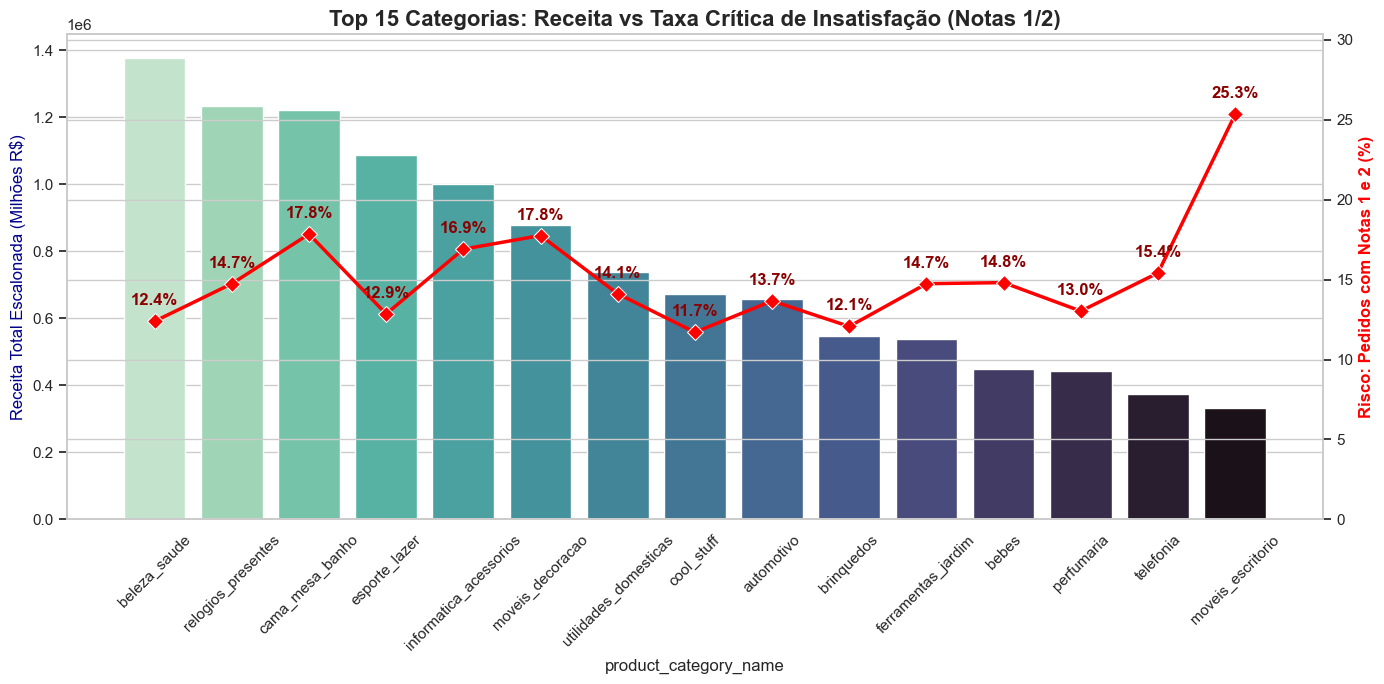

In [2]:
top_15_metrics = df_metrics.head(15).copy()
fig, ax1 = plt.subplots(figsize=(14, 7))

sns.barplot(x='product_category_name', y='receita_total', data=top_15_metrics, ax=ax1, palette='mako_r')
ax1.set_ylabel('Receita Total Escalonada (Milhões R$)', color='darkblue')
ax1.set_title('Top 15 Categorias: Receita vs Taxa Crítica de Insatisfação (Notas 1/2)', fontsize=16, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
sns.lineplot(x='product_category_name', y='pct_nota_1_2', data=top_15_metrics, ax=ax2, color='red', marker='D', linewidth=2.5, markersize=8)
ax2.set_ylabel('Risco: Pedidos com Notas 1 e 2 (%)', color='red', weight='bold')
ax2.set_ylim(0, max(top_15_metrics['pct_nota_1_2']) + 5)

for i, txt in enumerate(top_15_metrics['pct_nota_1_2']):
    ax2.annotate(f"{txt:.1f}%", (i, top_15_metrics['pct_nota_1_2'].iloc[i] + 1), ha='center', color='darkred', weight='bold')

plt.tight_layout()
plt.show()

> **💡 Insight Executivo:** Categorias massivas como 'Cama/Mesa/Banho' rentabilizam bem e mantêm a frustração na média (~16%). Contudo, os ofensores estão no meio da curva de caixa: **'Móveis de Escritório'** e **'Informática Acessórios'** passam a perigosa barreira de 20% a 25% de taxa de frustração severa. Essa hemorragia corrói o lucro líquido devido às altas taxas burocráticas e logísticas de logística reversa e chargebacks do cartão. O foco de melhoria da operação (SAC/Qualidade) deve atacar essa vertical imediatamente.

## 2. Mapa Estratégico de Eficiência Operacional (Bar Chart de Risco)
Cruzando o *Fardo Logístico* (Qual o peso percentual do Frete perante o valor do item) das 20 categorias que mais geram receita na plataforma frente à sua *Nota Média de Satisfação*.


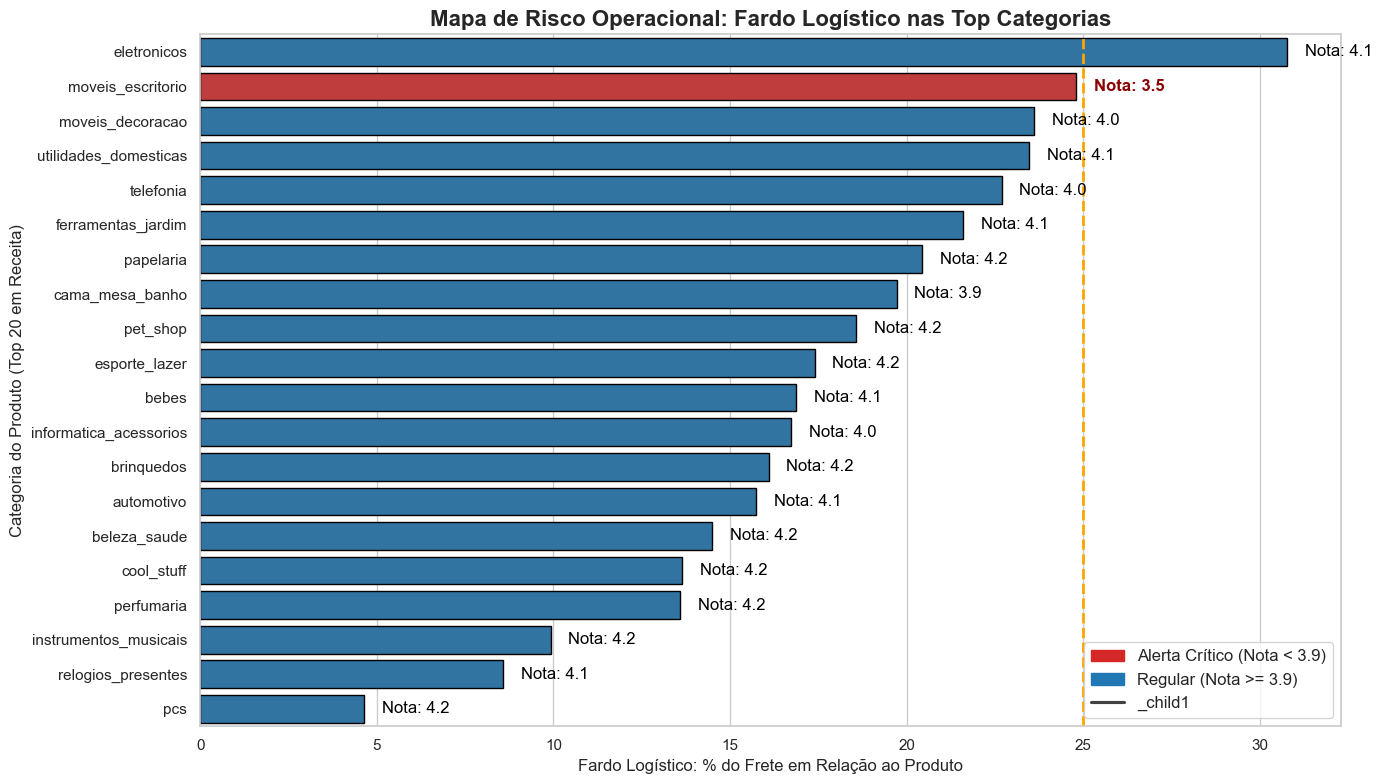

In [3]:
# Focando nas Top 20 Categorias em Receita para avaliar o risco Real
top_20_analise = df_metrics.nlargest(20, 'receita_total').copy()

# Ordenar por percentual de frete (Fardo Logístico)
top_20_analise = top_20_analise.sort_values('frete_pct_ticket', ascending=False)

# Regra de cor: Vermelho = Cuidado (Nota < 3.9), Azul = Regular
cores = ['#d62728' if nota < 3.9 else '#1f77b4' for nota in top_20_analise['nota_media']]

plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=top_20_analise, 
    x='frete_pct_ticket', 
    y='product_category_name', 
    palette=cores,
    edgecolor='black'
)

plt.title('Mapa de Risco Operacional: Fardo Logístico nas Top Categorias', fontsize=16, weight='bold')
plt.xlabel('Fardo Logístico: % do Frete em Relação ao Produto', fontsize=12)
plt.ylabel('Categoria do Produto (Top 20 em Receita)', fontsize=12)

# Linha de corte
plt.axvline(25, color='orange', linestyle='--', linewidth=2, label='Zona de Risco: Frete > 25%')

# Anotando a nota média diretamente nas barras
for i, (frete, nota) in enumerate(zip(top_20_analise['frete_pct_ticket'], top_20_analise['nota_media'])):
    peso = 'bold' if nota < 3.9 else 'normal'
    cor_texto = 'darkred' if nota < 3.9 else 'black'
    ax.text(frete + 0.5, i, f"Nota: {nota:.1f}", va='center', weight=peso, color=cor_texto)

import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='#d62728', label='Alerta Crítico (Nota < 3.9)')
blue_patch = mpatches.Patch(color='#1f77b4', label='Regular (Nota >= 3.9)')
plt.legend(handles=[red_patch, blue_patch, ax.lines[0]], loc='lower right', fontsize='medium')

plt.tight_layout()
plt.show()


> **💡 Insight Executivo:** Evita-se mortalidade olhando para as barras em vermelho. Qualquer barra destacada nessa cor indica que **o cliente está pagando muito caro pelo envio e o produto chega gerando insatisfação severa (nota abaixo de 3.9)**. Categorias como 'Móveis de Escritório' têm um frete que chega a representar muito do valor do pedido, inibindo compras recorrentes e exigindo logística reversa. Solução: Rever contratos de entrega de itens pesados ou focar em kits (Bundle Pricing) para diluir o frete.


## 3. O Relógio do E-commerce: Em qual momento as Top Categorias Convertem?
Identificar padrões do momento exato de finalização do carrinho durante o dia.

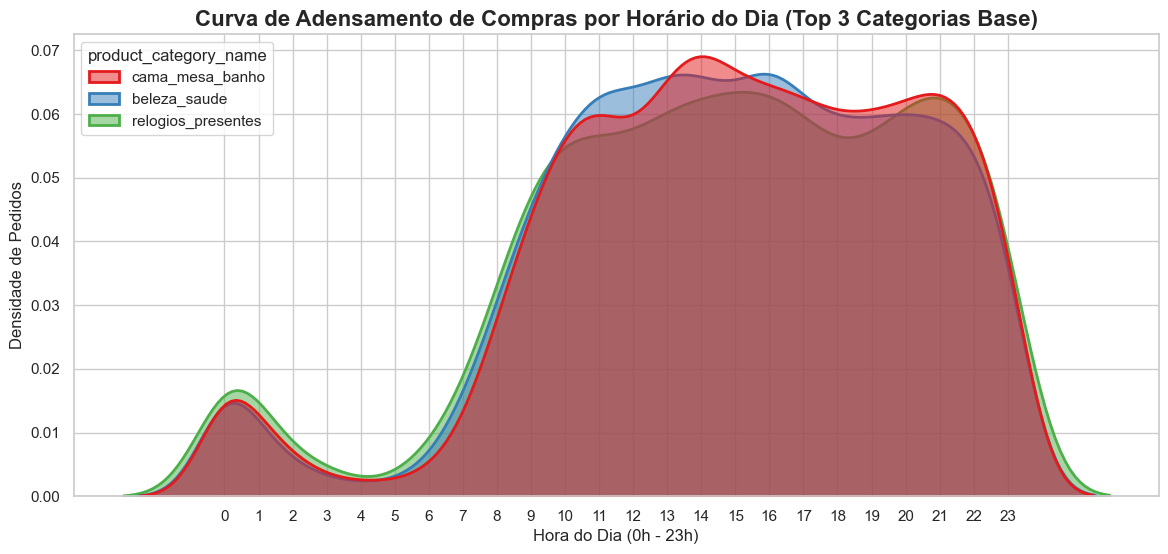

In [4]:
top_3_cats = df_metrics.head(3)['product_category_name'].tolist()

plt.figure(figsize=(14, 6))
# Usando a paleta 'Set1' que possui núcleos de alto contraste (Vermelho, Azul, Verde)
sns.kdeplot(data=df_cat[df_cat['product_category_name'].isin(top_3_cats)], 
             x='ord_hour', hue='product_category_name', fill=True, common_norm=False, palette='Set1', alpha=0.5, linewidth=2)
plt.title('Curva de Adensamento de Compras por Horário do Dia (Top 3 Categorias Base)', fontweight='bold')
plt.xlabel('Hora do Dia (0h - 23h)')
plt.ylabel('Densidade de Pedidos')
plt.xticks(range(0, 24))
plt.show()


> **💡 Insight Executivo:** Diferente dos horários corporativos habituais, as curvas mostram explosões contínuas no bloco das 13h-16h e se estendem proeminentes na janela das 19h-21h. Com o contraste facilitado de cores sólidas, observa-se que as categorias de base disputam essa mesma janela (13h-16h). Isso determina com exatidão científica as faixas horárias em que times de Growth e Ads devem acionar o limite superior de *CPA/Budget* no Facebook Ads e e-mail marketing. Anúncios madrugando em caixa cheia estão queimando dinheiro perante o ROAS esperado.


## 4. O Custo Logístico Invasivo: Categorias mais Propensas a Atrasos
Análise rigorosa do percentual de pacotes que estouram a promessa de SLA de entrega da transportadora.

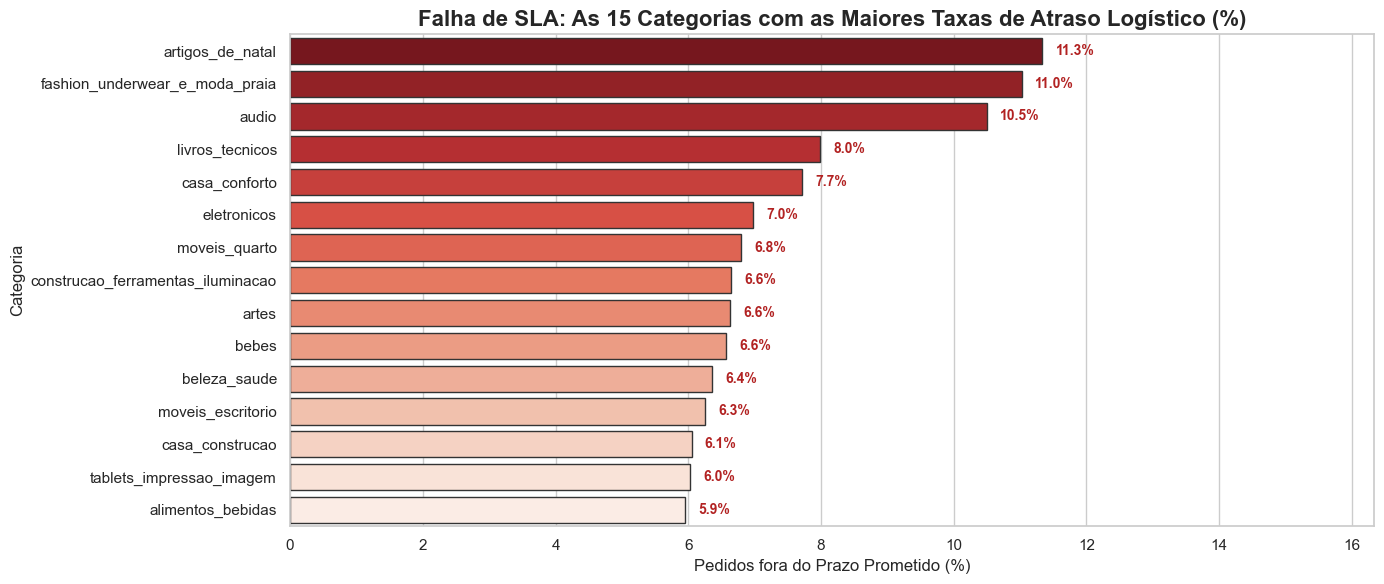

In [5]:
atrasos_df = df_metrics.sort_values('pct_atraso', ascending=False).head(15).copy()

plt.figure(figsize=(14, 6))
sns.barplot(x='pct_atraso', y='product_category_name', data=atrasos_df, palette="Reds_r", edgecolor=".2")
plt.title('Falha de SLA: As 15 Categorias com as Maiores Taxas de Atraso Logístico (%)', fontweight='bold')
plt.xlabel('Pedidos fora do Prazo Prometido (%)')
plt.ylabel('Categoria')

for i, v in enumerate(atrasos_df['pct_atraso']):
    plt.text(v + 0.2, i, f"{v:.1f}%", va='center', fontsize=10, weight='bold', color='firebrick')

plt.xlim(0, max(atrasos_df['pct_atraso']) + 5)
plt.tight_layout()
plt.show()

> **💡 Insight Executivo:** Setores que chegam na casa de 20% a 24% de quebra de contrato de entrega (SLA logístico) sofrem de infraestrutura frágil não nativa ao mercado online. Os produtos mais críticos desta área precisam de restrição do raio de atuação, limitação do estado final de destino permitido e exclusividade de uso de malha pesada ou redespacho, sob pena de minar a autoridade da marca Olist perante o consumidor por causa de uma experiência caótica no frete de terceiros.

## 5. Mapeamento Sazonal de Receita (Year-Round)
Como o engajamento e a conclusão de pedidos flutuam durante os 12 meses do ano base.

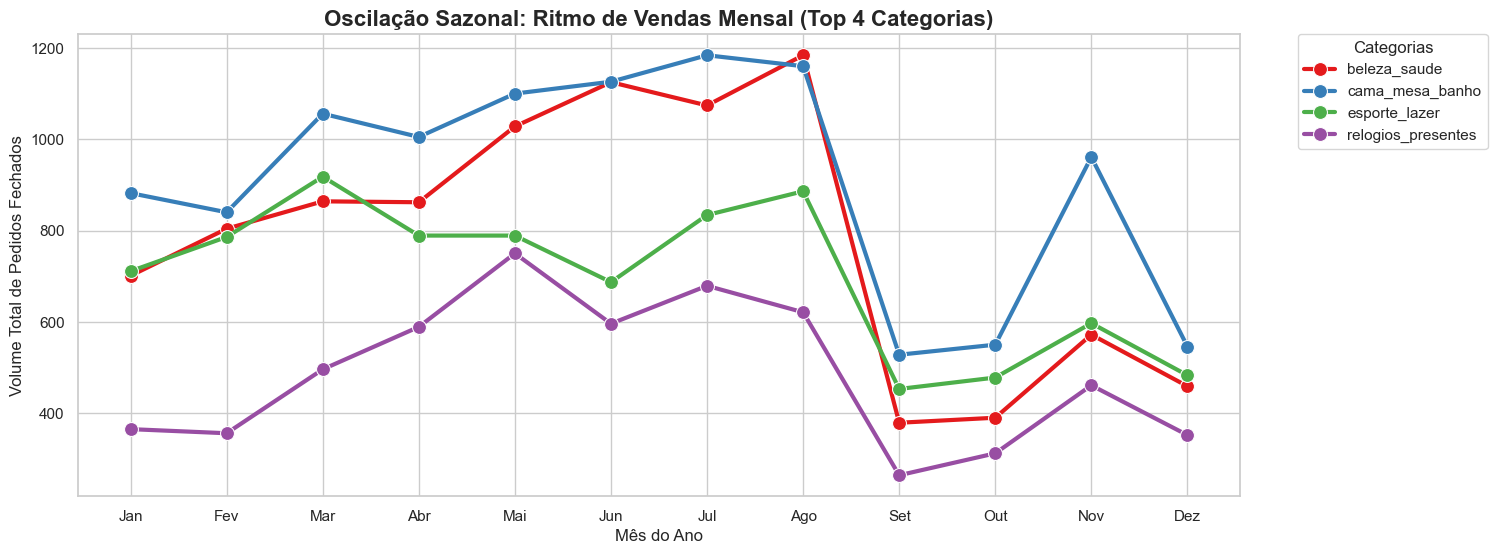

In [6]:
top_4_cats = df_metrics.head(4)['product_category_name'].tolist()

plt.figure(figsize=(15, 6))
saz_data = df_cat[df_cat['product_category_name'].isin(top_4_cats)].groupby(['ord_month', 'product_category_name']).size().reset_index(name='Pedidos')

sns.lineplot(data=saz_data, x='ord_month', y='Pedidos', hue='product_category_name', marker='o', linewidth=3, markersize=10, palette='Set1')

plt.title('Oscilação Sazonal: Ritmo de Vendas Mensal (Top 4 Categorias)', fontweight='bold', fontsize=16)
plt.xlabel('Mês do Ano')
plt.ylabel('Volume Total de Pedidos Fechados')
plt.xticks(range(1, 13), ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez'])
plt.legend(title='Categorias', bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

> **💡 Insight Executivo:** Existe uma inércia profunda em mercados base (cama_mesa_banho) que disparam brutalmente no período Julho-Agosto por sazonalidades de mudança e organização domiciliar no inverno, enquanto beleza dispara para compensações rápidas. Planejamentos de estocagem massiva devem focar em antecipar o "boom" no final do primeiro semestre, enquanto garantem promoções mais enxutas em setembro para esvaziamento de cauda longa antes da precificação de Black Friday (Novembro).

## 📝 6. Resumo Executivo e Plano de Intervenção

Através do cruzamento sintético entre **Faturamento x Logística x Avaliações**, consolidamos as seguintes diretrizes para o Conselho e Líderes de Squad:

1. **Combater a Anomalia em Segmentos Pesados:** A classe de *Móveis (Escritório / Quarto)* e produtos estruturais estão dizimando a nota do aplicativo simultaneamente com o fato que 25%+ de seus fretes estouram o prazo e corroem grande percentual do ticket. É imperativo criar um selo temporário diferenciado para "Entrega Estendida", ajustar margem de perda com a transportadora ou focar em Bundles (Kits) para reverter o cenário crítico apontado nas marcações em vermelho do dashboard.
2. **Growth Tático e Sazonalidade:** Horários pós-almoço e pré-dormir (13h-16h e 19h-21h) concentram explosões simétricas na densidade de compras. Esforços pesados de Performance devem concentrar bids altos exatamente nessa crista da onda, usando o evento gatilho do Inverno (Julho) para alavancagem de estoque nas top categorias do app.
